# Code Assignment — Residual ACF/PACF + Prophet (Builds on Last COVID-19 TS Assignment)

**Dataset (local CSV):** NYC COVID-19 daily counts (static export)  
**Target:** `case_count`

## Instructor Guidance (Documentation + Pseudocode)

**Docs**
- statsmodels ARIMA: https://www.statsmodels.org/stable/generated/statsmodels.tsa.arima.model.ARIMA.html  
- ADF (adfuller): https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.adfuller.html  
- ACF/PACF: https://www.statsmodels.org/stable/graphics.html#autocorrelation-plots  
- Prophet: https://facebook.github.io/prophet/docs/quick_start.html  
- RMSE (sklearn MSE): https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html  

**Pseudocode Workflow**
1) **Load CSV** → normalize columns; parse date.  
2) **Build daily time series** using `date_of_interest` as index; target = `case_count`; `asfreq('D')`; `interpolate('linear')`.  
3) **Chronological split (80/20)** → `train = first 80%`, `test = last 20%`.  
4) **Stationarity check (given)** → ADF on **differenced train**.  
5) **Baseline forecast (given)** → last train value for all test steps; compute **RMSE**.  
6) **ARIMA(1,1,1) (given)** → fit on **train**, forecast `len(test)`, compute **RMSE**; save **residuals**.  
7) **YOU DO:** Plot **ACF** and **PACF** of ARIMA **residuals**; comment on significant lags vs. bands.  
8) **YOU DO:** Fit **Prophet** on **train**, forecast over **test** horizon, compute **RMSE**, and plot vs. actuals.  
9) **YOU DO:** Plot residuals over time and write a 2–3 sentence interpretation.  
10) **Compare RMSEs** (Baseline vs. ARIMA vs. Prophet) and reflect on which generalizes best.

> **Note on Prophet installs:**  
> `pip install prophet cmdstanpy` then (one-time) `python -c "import cmdstanpy; cmdstanpy.install_cmdstan()"`.


In [1]:
# STEP 0 — Imports  |  RUN THIS CELL WITHOUT CHANGES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

# For YOUR ACF/PACF step later
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


### Step 1 — Load CSV and preview 


In [2]:
# RUN THIS CELL WITHOUT CHANGES Except changing filepath
DATA_PATH = "../data/covid copy.csv"   # <-- update path

df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.lower().str.strip()

date_col = "date_of_interest"
target_col = "case_count"

df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
df = df.dropna(subset=[date_col]).sort_values(date_col)

# Coerce target to numeric (handles '1,141' strings)
df[target_col] = pd.to_numeric(df[target_col].astype(str).str.replace(",", "", regex=False), errors="coerce")

print(df.head())
print("Range:", df[date_col].min(), "→", df[date_col].max())


  date_of_interest  case_count probable_case_count hospitalized_count  \
0       2020-02-29           1                   0                  1   
1       2020-03-01           0                   0                  1   
2       2020-03-02           0                   0                  2   
3       2020-03-03           1                   0                  7   
4       2020-03-04           5                   0                  2   

   death_count case_count_7day_avg all_case_count_7day_avg  \
0            0                   0                       0   
1            0                   0                       0   
2            0                   0                       0   
3            0                   0                       0   
4            0                   0                       0   

  hosp_count_7day_avg  death_count_7day_avg bx_case_count  ... si_case_count  \
0                   0                     0             0  ...             0   
1                   0       

### Step 2 — Build daily time series and fill small gaps
- Set date index, `asfreq('D')`, `interpolate('linear')`.

In [3]:
# RUN THIS CELL WITHOUT CHANGES
s = df.set_index(date_col)[target_col].asfreq("D")
s = s.astype("float64").interpolate("linear")

print("Series:", target_col, "| length:", len(s), "| range:", s.index.min().date(), "→", s.index.max().date())
s.head()


Series: case_count | length: 2054 | range: 2020-02-29 → 2025-10-13


date_of_interest
2020-02-29   1.000
2020-03-01   0.000
2020-03-02   0.000
2020-03-03   1.000
2020-03-04   5.000
Freq: D, Name: case_count, dtype: float64

### Step 3 — Chronological split (80/20)
- First 80% → **train**; last 20% → **test**.


Train: 2020-02-29 → 2024-08-28 | n = 1643
Test : 2024-08-29 → 2025-10-13 | n = 411


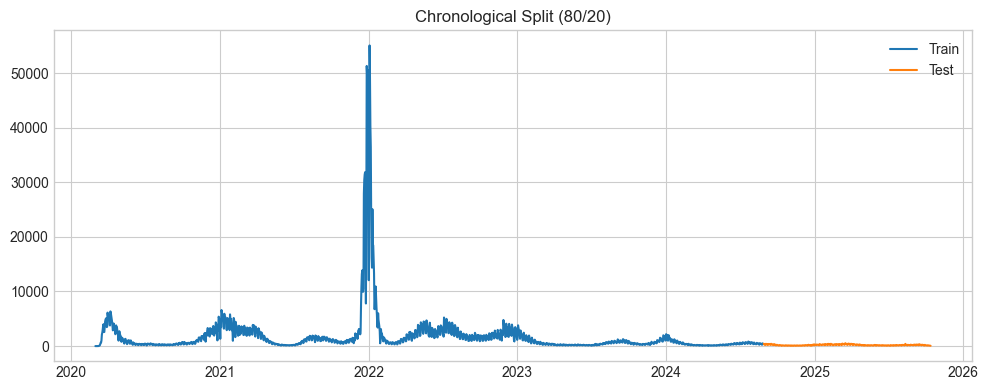

In [4]:
# RUN THIS CELL WITHOUT CHANGES
split_idx = int(len(s) * 0.80)
train = s.iloc[:split_idx]
test  = s.iloc[split_idx:]

print("Train:", train.index.min().date(), "→", train.index.max().date(), "| n =", len(train))
print("Test :", test.index.min().date(),  "→", test.index.max().date(),  "| n =", len(test))

plt.figure(figsize=(10,4))
plt.plot(train, label="Train")
plt.plot(test,  label="Test", color="#ff7f0e")
plt.title("Chronological Split (80/20)")
plt.legend(); plt.tight_layout(); plt.show()


In [20]:
train.info()

<class 'pandas.core.series.Series'>
DatetimeIndex: 1643 entries, 2020-02-29 to 2024-08-28
Freq: D
Series name: case_count
Non-Null Count  Dtype  
--------------  -----  
1643 non-null   float64
dtypes: float64(1)
memory usage: 25.7 KB


### Step 4 — ADF on **differenced train** (stationarity check)
- If p < 0.05, **d=1** is reasonable in ARIMA.


In [5]:
# RUN THIS CELL WITHOUT CHANGES
diff_train = train.diff().dropna()
adf_stat, adf_p, _, _, crit, _ = adfuller(diff_train)
print(f"[ADF on differenced TRAIN] stat={adf_stat:.3f}, p={adf_p:.4f}")
for k, v in crit.items():
    print(f"  critical {k}: {v:.3f}")


[ADF on differenced TRAIN] stat=-9.677, p=0.0000
  critical 1%: -3.434
  critical 5%: -2.863
  critical 10%: -2.568


### Step 5 — Baseline (naïve/shift) forecast + RMSE
- Forecast = last train value repeated.

Baseline RMSE: 215.047


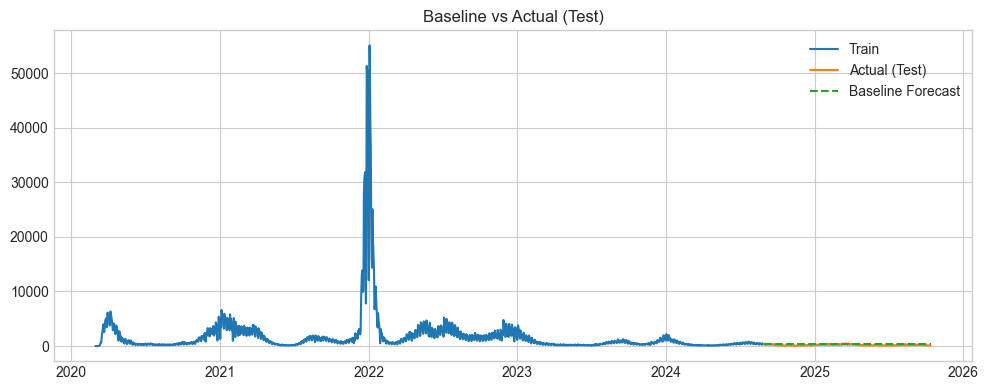

In [8]:
# RUN THIS CELL WITHOUT CHANGES
baseline_pred = pd.Series(train.iloc[-1], index=test.index)
rmse_baseline = np.sqrt(mean_squared_error(test, baseline_pred))
print(f"Baseline RMSE: {rmse_baseline:,.3f}")

plt.figure(figsize=(10,4))
plt.plot(train, label="Train")
plt.plot(test, label="Actual (Test)", color="#ff7f0e")
plt.plot(baseline_pred, label="Baseline Forecast", color="#2ca02c", ls="--")
plt.title("Baseline vs Actual (Test)")
plt.legend(); plt.tight_layout(); plt.show()


### Step 6 — ARIMA(1,1,1) fit → forecast → RMSE
- Fit on **train** only; forecast length = `len(test)`.

ARIMA(1,1,1) RMSE: 261.128


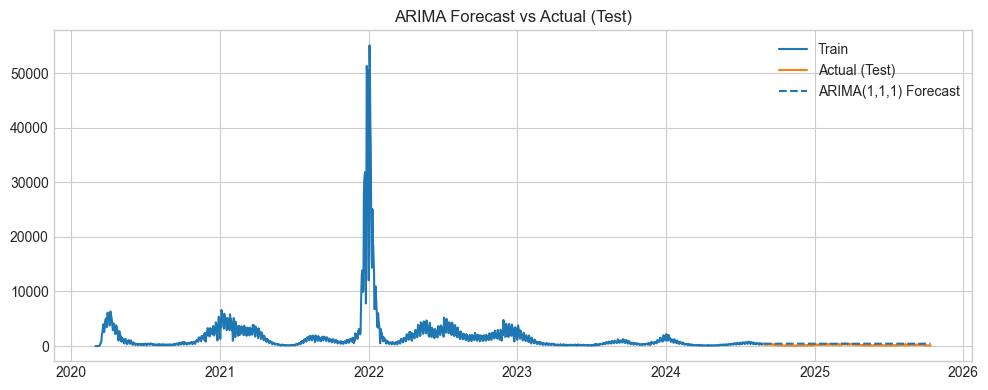

In [10]:
# RUN THIS CELL WITHOUT CHANGES
arima_model = ARIMA(train, order=(1, 1, 1)).fit()
pred_arima = arima_model.forecast(steps=len(test))
rmse_arima = np.sqrt(mean_squared_error(test, pred_arima))
residuals = arima_model.resid  # save for diagnostics
print(f"ARIMA(1,1,1) RMSE: {rmse_arima:,.3f}")

plt.figure(figsize=(10,4))
plt.plot(train, label="Train")
plt.plot(test, label="Actual (Test)", color="#ff7f0e")
plt.plot(pred_arima, label="ARIMA(1,1,1) Forecast", color="#1f77b4", ls="--")
plt.title("ARIMA Forecast vs Actual (Test)")
plt.legend(); plt.tight_layout(); plt.show()


### Step 7 — YOU DO: Residual Diagnostics with ACF & PACF
- Plot **ACF** and **PACF** of `residuals` (from ARIMA).  
- Interpretation cues:
  - **Good:** bars mostly within bands → residuals ≈ white noise.  
  - **Spike at lag 7 or 12:** missed weekly/monthly seasonality → consider SARIMA.  
  - **PACF spike at lag p:** consider higher AR(p).  
  - **ACF spike at lag q:** consider higher MA(q).


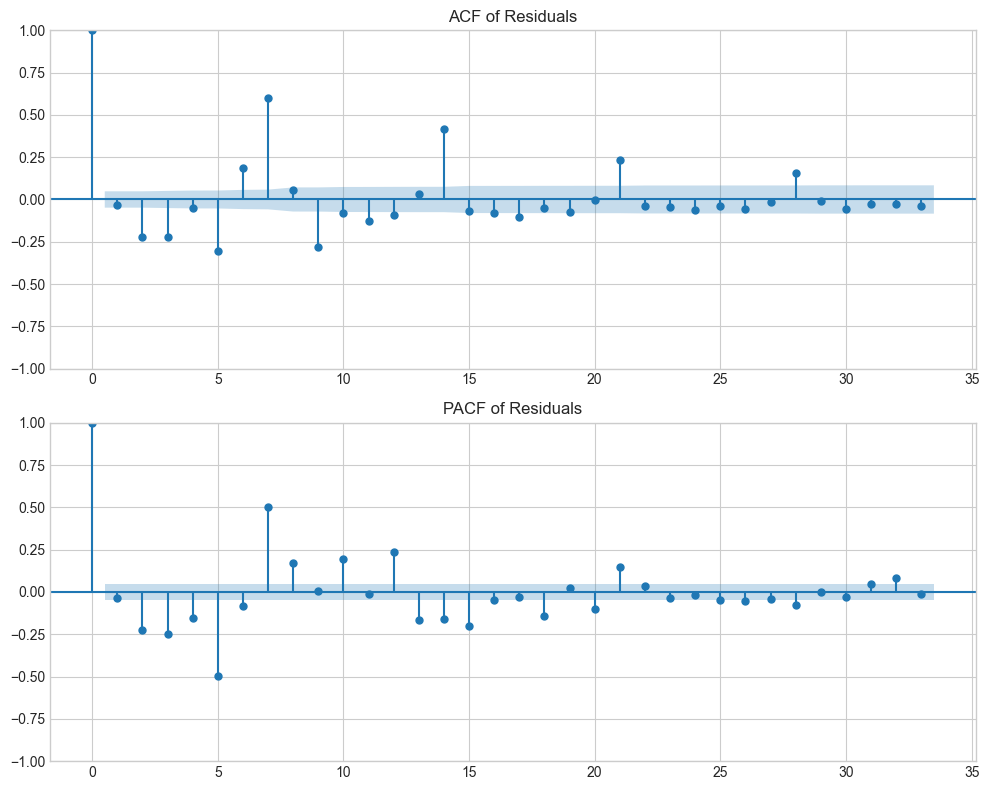

In [ ]:
# Create a figure for the plots
fig, ax = plt.subplots(2, 1, figsize=(10, 8))

# Plot the ACF of the residuals
plot_acf(residuals, ax=ax[0])
ax[0].set_title('ACF of Residuals')

# Plot the PACF of the residuals
plot_pacf(residuals, ax=ax[1])
ax[1].set_title('PACF of Residuals')

plt.tight_layout()
plt.show()

# many significant marks, more than 8 are significantly outside of the band, but many of our total residuals are within the edge or outside.

### Step 8 — YOU DO: Prophet model → forecast → RMSE
- Fit **Prophet** on **train** (rename columns to `ds` and `y`).  
- Forecast over the **test** horizon (same dates as `test.index`).  
- Compute **RMSE** and plot vs. actual.  
- If installation errors occur, install:
  - `pip install prophet cmdstanpy`
  - one-time: `python -c "import cmdstanpy; cmdstanpy.install_cmdstan()"`


In [63]:
from prophet import Prophet

prophettrain = df.iloc[:split_idx]
ptrain = prophettrain[['date_of_interest','case_count']]
prophettest  = df.iloc[split_idx:]
ptest = prophettest[['date_of_interest','case_count']]

ptrain = ptrain.rename(columns={'date_of_interest':'ds','case_count':'y'})
ptest = ptest.rename(columns={'date_of_interest':'ds','case_count':'y'})

ptest['y'] = ptest['y'].astype(float)


14:15:17 - cmdstanpy - INFO - Chain [1] start processing
14:15:17 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
406,2025-10-09,-133.063,"-5,117.099","4,924.112"
407,2025-10-10,-431.732,"-5,320.300","4,875.755"
408,2025-10-11,"-1,013.463","-6,246.628","4,006.117"
409,2025-10-12,-900.540,"-6,082.410","4,322.631"
410,2025-10-13,161.044,"-4,797.148","5,225.122"


prophets rmse is: 2123.5908501186686


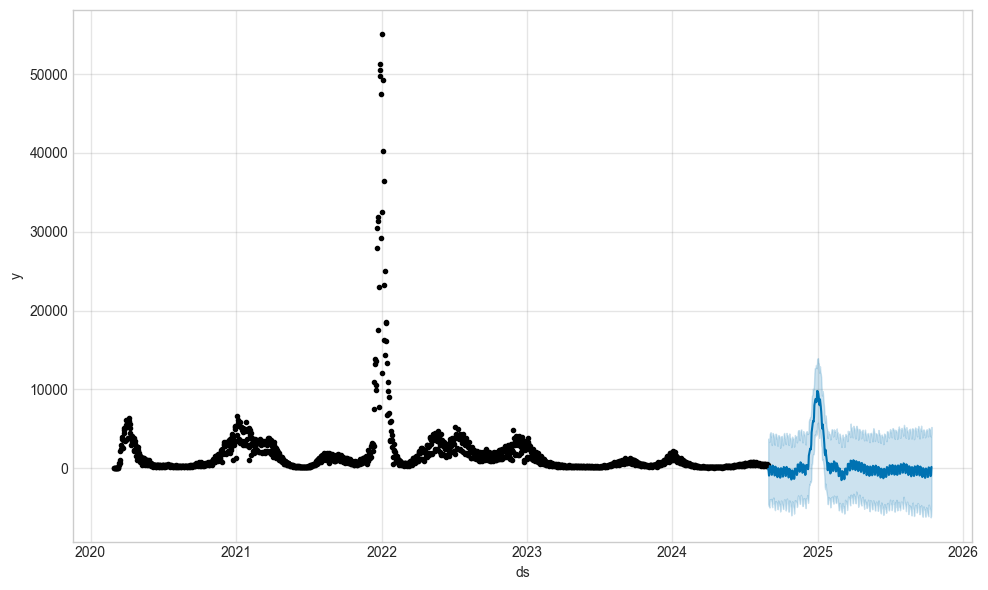

In [80]:
m = Prophet()
m.fit(ptrain)
trainpredict = m.predict(ptest)
fig1 = m.plot(trainpredict)


display(trainpredict[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())
prophet_rmse = np.sqrt(mean_squared_error(ptest['y'], trainpredict['yhat']))

print('prophets rmse is:',prophet_rmse)


### Step 9 — YOU DO: Residuals over time + short interpretation
- Plot `residuals` vs. time; aim for random scatter around 0.  
- Write 2–3 sentences: Do residuals look like white noise? If not, what would you try (adjust p/q, SARIMA)?


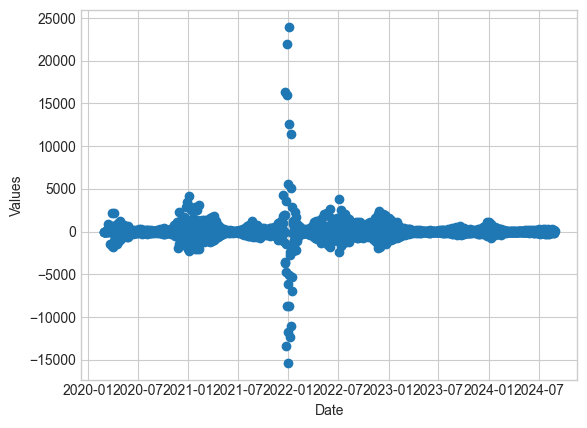

In [90]:
plt.scatter(residuals.index, residuals)
plt.xlabel('Date')
plt.ylabel('Values')
plt.show()

The residuals do not look like white noise as we have a large spike in 2022. This is also supported in the ACF and PACF as our residuals do not fit within our significance boundaries. This means there are other patterns that have not been captured in our model, so we can try SARIMA and find if there are any seasonal patterns.

### Step 10 — YOU DO:  Compare RMSEs and declare a winner
- Create a small table with Baseline, ARIMA, Prophet RMSEs.  
- Which model generalized best? By how much vs. baseline?


In [91]:
compared_rmse = pd.DataFrame({
    'Model': ['Baseline',' ARIMA(1,1,1)','Prophet'],
    'RMSE': [rmse_baseline, rmse_arima, prophet_rmse]
})

display(compared_rmse)

,Model,RMSE
0,Baseline,215.047
1,"ARIMA(1,1,1)",261.128
2,Prophet,"2,123.591"


## We Share — Reflection
- Did ACF/PACF suggest remaining structure (specific lags)? What change would you try first?  

The ACF/PACF did suggest remaining structure, as we had high peaks and values that fell outside the significance boundaries. I would try first to adjust our ARIMA (p,d,q) as it is the quickest to adjust and see change. Because we are seeing spikes in our ACF and PCAF, it is suggested to increase the p and q. 

- Which model won on **RMSE**? Any business intuition why (trend shifts, seasonality, holiday effects)?  

Surprisingly, our baseline model performed the best and had the lowest RMSE. A likely reason is due to the large spike in our training data during 2022. Since it is unlikely to occur again, ARIMA and especially Prophet model try to model it as part of the pattern, which hurts the accuracy. The baseline model avoids overfitting to the spike and is more generalized.

- If this went to production, what **guardrails** (intervals, fallback baseline, anomaly flags) would you put in place?

One guardrail I would implement is revenue, since the model could potentially over-forecast cases and lead to unnecessary staffing. Tracking revenue as a guardrail would also indicate how well the model is performing. If we observe a decline in hospital revenue, we could recalibrate the ARIMA or Prophet model using more recent data.